# Superstore Dataset Analysis

## Dataset Overview

The superstore dataset contains transactional data related to sales, profit, customers and products from a retail business. I use this dataset to explore patterns in sales performanc, customer behavior, and regional profitability.

___

## Objective

The goal of this project is to analyze the dataset using **Pandas** and extract meaningful insights that can help improve business decisions.

Specifically, I focus on:

✔️ Identifying profitable products and categories

✔️ Analyzing performance across regions

✔️ Understanding customer segments

✔️ Observing treds over time

## Importing important libraries

In this step, I imported the main **Python** libraries that are needed for data analysis and visualization. These libraries help in handling data, performing calculations, and creating plots.

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Loading the dataset

I loaded the Superstore dataset into a **Pandas DataFrame**. The dataset contains information about sales, profit, customers, products, and regions.

In [29]:

url = "https://raw.githubusercontent.com/Ale-chamada/Superstore-Data-Analysis-using-Pandas/main/data/Sample%20-%20Superstore.csv"

df = pd.read_csv(url, encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Exploring the Data

I explored the dataset to understande its structure, including column names, data types, and missing values.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Summary Statistics

I generated summary statistics to understand the distribution of numerical values such as sales, profit, quantity, and discount.

In [31]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Data Cleaning

I checked for missing values and handled them to ensure data completeness. I also converted the date columns into datetime format so that time-based analysis can be performed easily.

## Checking Missing Values

I checked if there are any msissing values in the dataset.This helps to understand whether any data cleaning is required.

In [32]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


## Handling Missing Values

I handled missing values to ensure the dataset is complete and ready for analysis. Since the dataset is clean, I removed any missing records.

In [33]:
df = df.dropna()

## Converting Data Types

I converted the date columns into datetime format. This is important for time-based analysis like monthly or yearly trends.

In [34]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

## Feature Engineering

I performed feature engineering by creating new useful columns from existing data.This hepls in better analysis of time trends and profitability patterns.

## Extract Month and Year

I extracted the **month** and **year** from the Order Date column to enable time-based analysis.

In [35]:
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

## Creating a New Column

I created a new column called **Profit Margin** using existing numerical columns(Profit and Sales to better understand profitability.

In [36]:
df['Profit Margin'] = df['Profit'] / df['Sales']

## Verifying the New Column

I checked the new column to ensure it was calculated correctly and logically makes sense

In [37]:
df[['Sales', 'Profit', 'Profit Margin']].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


##### New columns like Order Month, Order Year, and Profit Margin were created from the Order Date and existing numerical data to support time-based and profitability analysis.

## GroupBy and Aggregation

I used groupby and aggregation function to analyze sales and profit across categories, regions, and customers. This helps in identifying top-performing areas and understanding sales trends over time.

## Total Sales by Category

I calculated the total sales for each product category to understand which category performs best.

In [38]:
df.groupby('Category')['Sales'].sum().reset_index()

,Category,Sales
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


## Total Profit by Region

I calculated total profit across different regions to compare performance.

In [39]:
df.groupby('Region')['Profit'].sum().reset_index()

,Region,Profit
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108418.4489


## Top 5 Customers by Sales

I identified the top 5 customers based on total sales to see the most valuable customers.

In [40]:
df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5).reset_index()

,Customer Name,Sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571


## Monthly Sales Trend

I analyzed sales trends over time by grouping sles by year and month.

In [41]:
df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()

,Order Year,Order Month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


##### The analysis shows that Technology has the highest sales, the West region has the highest profit, top customers contribute most of the revenue, and sales fluctuate monthly with seasonal peaks.

## Pivot Tables

Used to summarize and compare sales and profit across categories, regions, segments, and sub-categories. This helps in identifying patterns and high-performing areas in the dataset.

## Sales by Category and Region

I created a pivot table to analyze total sales acress different categories and regions.

In [42]:
pivot = df.pivot_table(values='Sales', index='Category', columns='Region', aggfunc='sum')

pivot = pivot.reset_index()
pivot.columns.name = None

pivot

,Category,Central,East,South,West
0,Furniture,163797.1638,208291.204,117298.684,252612.7435
1,Office Supplies,167026.4150,205516.055,125651.313,220853.2490
2,Technology,170416.3120,264973.981,148771.908,251991.8320


## Sales Trends by segement over time

I analyzed how sales change over time for each customer segment using year and month.

In [43]:
pd.pivot_table(df, values='Sales', index=['Order Year', 'Order Month'], columns='Segment', aggfunc='sum').reset_index()


Segment,Order Year,Order Month,Consumer,Corporate,Home Office
0,2014,1,6927.8170,1701.5280,5607.5500
1,2014,2,3167.8540,1183.6680,168.3700
2,2014,3,11869.3040,11106.7990,32714.9060
3,2014,4,9108.6120,14131.7290,5055.0040
4,2014,5,12819.1630,9142.0000,1687.1240
5,2014,6,25923.7476,3970.9140,4700.4660
6,2014,7,20197.7400,10032.9880,3715.6650
7,2014,8,16215.2635,7451.7740,4242.4310
8,2014,9,59690.6500,15507.7450,6578.9558
9,2014,10,16246.6970,12637.6780,2569.0180


## Profit by Sub-Category

I created a pivot table to understand which sub-categories generate the most profit.

In [44]:
pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum').reset_index()

,Sub-Category,Profit
0,Accessories,41936.6357
1,Appliances,18138.0054
2,Art,6527.7870
3,Binders,30221.7633
4,Bookcases,-3472.5560
5,Chairs,26590.1663
6,Copiers,55617.8249
7,Envelopes,6964.1767
8,Fasteners,949.5182
9,Furnishings,13059.1436


##### Technology performs best across all regions, the Consumer segment dominates sales, and some sub-categories generate losses while others are highly profitable.

## Data Spliting and Merging

I split the data into sales and customer information to organize the analysis.Later, I merged them back using **Order ID** to ensure the dataset stays complete and consistent for further analysis.

## Split the Dataset

I split the dataset into two meaningful DataFrames:

✔️ df_sales_info: product and sales-related columns

✔️ df_customer_info: customer and location-related columns

In [45]:
df_sales_info = df[['Order ID', 'Product ID', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']]

df_customer_info = df[['Order ID', 'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Region']]

## Merge the Datasets back

I merged both **DataFrames** using **Order ID**, which is the common key.

In [46]:
merged_df = pd.merge(df_sales_info, df_customer_info, on='Order ID')
merged_df.head()

,Order ID,Product ID,Category,Sub-Category,Sales,Quantity,Discount,Profit,Customer ID,Customer Name,Segment,City,State,Region
0,CA-2016-152156,FUR-BO-10001798,Furniture,Bookcases,261.96,2,0.0,41.9136,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South
1,CA-2016-152156,FUR-BO-10001798,Furniture,Bookcases,261.96,2,0.0,41.9136,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South
2,CA-2016-152156,FUR-CH-10000454,Furniture,Chairs,731.94,3,0.0,219.5820,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South
3,CA-2016-152156,FUR-CH-10000454,Furniture,Chairs,731.94,3,0.0,219.5820,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,South
4,CA-2016-138688,OFF-LA-10000240,Office Supplies,Labels,14.62,2,0.0,6.8714,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,West


## Verfiy correctness

To ensure the merge is correct!

In [47]:
merged_df.shape
merged_df.isnull().sum()

,0
Order ID,0
Product ID,0
Category,0
Sub-Category,0
Sales,0
Quantity,0
Discount,0
Profit,0
Customer ID,0
Customer Name,0


##### The dataset was split into sales and customer data for better organization and then merged back using Order ID, ensuring data consistency and integrity.

## Data Visualization

I used **Pandas** visualization tools to explore sales, profit, and segment patterns in rhe Superstore dataset. The goal is to understand trends and comparisons across different dimensions.

## Line Chart - Sales Trend over time

Used to show how sales change across years and months.

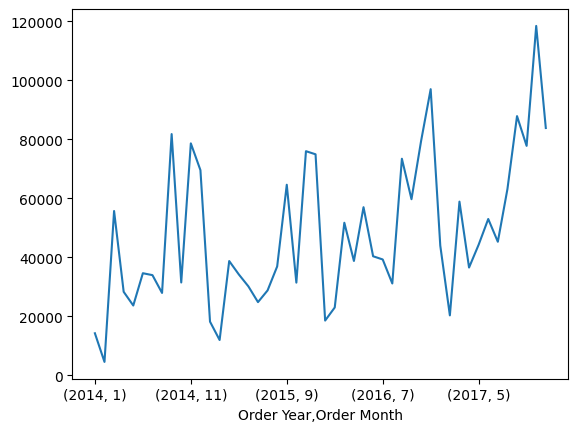

In [48]:
df.groupby(['Order Year','Order Month'])['Sales'].sum().plot(kind='line')
plt.show()

## Bar Chart - Sales by Category

Used to compare total sales across product categories.

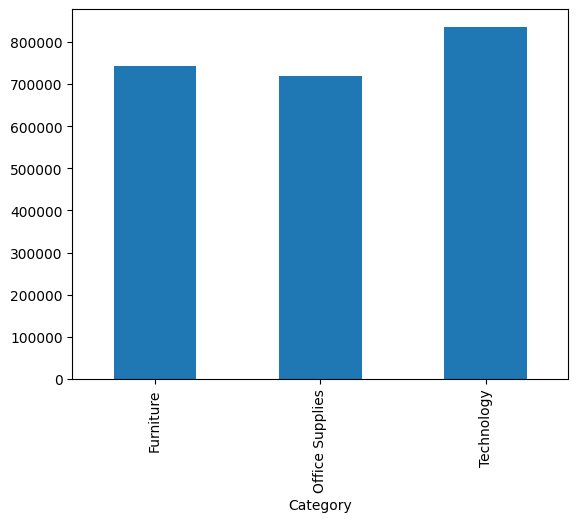

In [49]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.show()

## Bar Chart - Profit by Region

Used to compare profit performance across regions.

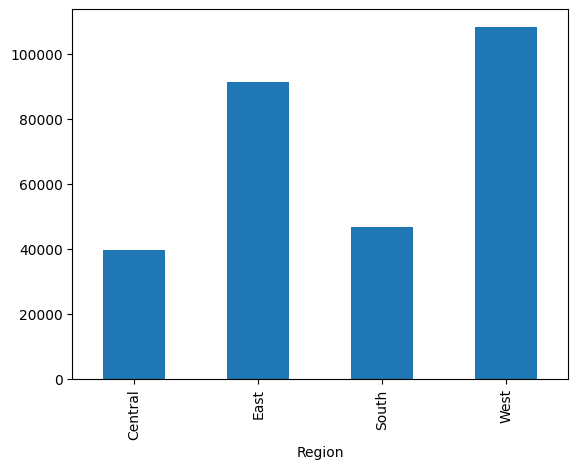

In [50]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.show()

## Pie Chart - Segment Distribution

Used to show proportion of sales by customer segment.

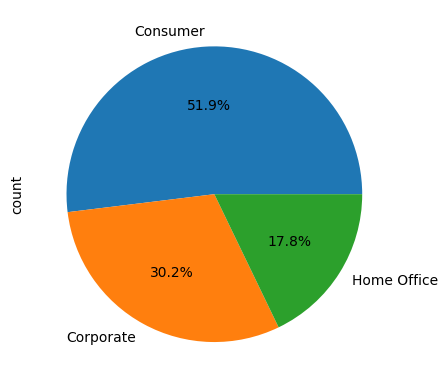

In [51]:
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

##### Visualizations show that sales peak during certain months (especially year-end), Technology leads in sales, West region has the highest profit, and Consumer segment dominates overall distribution.

# Final Insights

##### ✔️ The most profitable category is Technology, as it generates the highest total profit compared to Furniture and Office Supplies.

##### ✔️ The Central region performs the weakest in terms of profit compared to East, West, and South regions.

##### ✔️ There is a positive relationship between sales and profit in most cases, but not always. Some high-sales products still show low or negative profit due to discounts.

##### ✔️ Sales show a seasonal pattern, with higher performance in Q4 (Oct–Dec) and lower values in early months. Overall, sales and profit fluctuate but tend to peak toward the end of each year.